# ぼやけ(blur)概念消去 結果まとめ

`0007_blur_score` → `0008_erace_blur`(LEACE) → `0009_erace_qe`(QuadraticEraser) →
`0010_finding_utility_check`(本番規模998スライド) の一連の実験結果を可視化する。

- 0007: 全998スライド(998,000パッチ)のぼやけスコア(Laplacian分散)を算出
- 0008/0009: 10スライドの小規模検証で、LEACE(線形)/QuadraticEraser(非線形)それぞれの消去力を確認
- 0010: 998スライド全数で、ぼやけ消去が病理所見検出(has_finding)のutilityを壊していないかを検証(本レポートの主結果)

以降の図は主に0010(998スライド全数、本番規模)の数値を使う。0008/0009は10スライドの
予備検証だが、傾向(LEACEは線形のみ・QuadraticEraserはより広く消す)は0010と整合している。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- reference palette (see dataviz skill: references/palette.md) ---
BLUE = "#2a78d6"     # categorical slot 1
ORANGE = "#eb6834"   # categorical slot 2
AQUA = "#1baf7a"      # categorical slot 3

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Lato", "Arial"],
    "svg.fonttype": "none",
})

# NOTE: this environment has no CJK-capable font installed, so chart text
# (titles/axis/legend) is kept in English to avoid tofu-box glyphs.
# Narrative context stays in Japanese in the markdown cells around each figure.


def load_results(exp_dir_name: str) -> dict:
    path = OUTPUTS / exp_dir_name / "default" / "results.json"
    with open(path) as f:
        return json.load(f)


r0007 = load_results("0007_20260801_blur_score")
r0008 = load_results("0008_20260801_erace_blur")
r0009 = load_results("0009_20260803_erace_qe")
r0010 = load_results("0010_20260803_finding_utility_check")

print("0007 (blur score, full 998 slides):", r0007)


0007 (blur score, full 998 slides): {'n_slides': 998, 'n_patches': 998000, 'blur_score_mean': 1204.182373046875, 'blur_score_std': 641.343994140625, 'blur_score_min': 0.0, 'blur_score_max': 5387.1787109375}


## Fig 1 — ぼやけスコアの分布(998,000パッチ、0007)

Laplacian分散を998スライド×1000パッチ/スライド全数に適用した分布。以降の全実験は、この
連続値を「ぼやけ」というconceptのラベルとして使う。


In [2]:
# 0007 saved a per-slide memmap of raw patch-level blur scores; load them all
# to draw the true distribution (results.json only stores summary stats).
blur_dir = OUTPUTS / "0007_20260801_blur_score" / "default" / "blur_score_output"
slide_dirs = sorted(d for d in blur_dir.iterdir() if d.is_dir())

parts = []
for d in slide_dirs:
    meta = json.loads((d / "meta_blur.json").read_text())
    n = meta["shape"][0]
    arr = np.memmap(d / "blur_scores.dat", dtype=meta["dtype"], mode="r", shape=(n,))
    parts.append(np.asarray(arr))

blur_scores = np.concatenate(parts)
assert blur_scores.shape[0] == r0007["n_patches"]
print(f"{len(slide_dirs)} slides, {blur_scores.shape[0]:,} patches")
print(f"mean={blur_scores.mean():.1f} std={blur_scores.std():.1f} "
      f"min={blur_scores.min():.1f} max={blur_scores.max():.1f}")


998 slides, 998,000 patches
mean=1204.2 std=641.3 min=0.0 max=5387.2


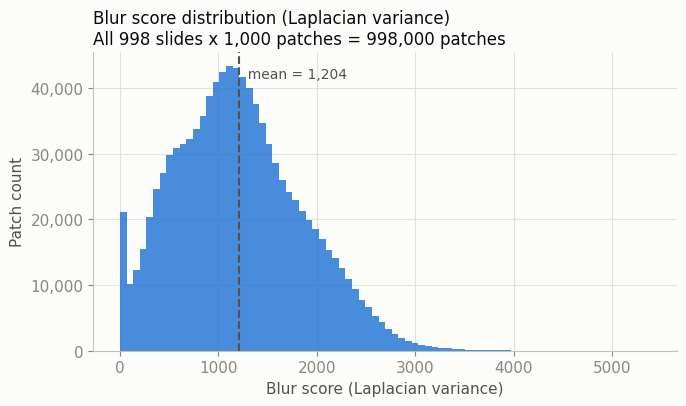

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.hist(blur_scores, bins=80, color=BLUE, alpha=0.85, linewidth=0)

mean_val = blur_scores.mean()
ax.axvline(mean_val, color=INK_SECONDARY, linewidth=1.5, linestyle="--")
ax.text(
    mean_val, ax.get_ylim()[1] * 0.95, f"  mean = {mean_val:,.0f}",
    color=INK_SECONDARY, va="top", ha="left", fontsize=10,
)

ax.set_title("Blur score distribution (Laplacian variance)\nAll 998 slides x 1,000 patches = 998,000 patches", loc="left", color=INK_PRIMARY, fontsize=12)
ax.set_xlabel("Blur score (Laplacian variance)")
ax.set_ylabel("Patch count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_blur_score_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## Fig 2 — ぼやけの残存度(消去前 / LEACE後 / QuadraticEraser後)

UNI特徴量からぼやけスコアをどれだけ予測できるか(=ぼやけ情報がどれだけ残っているか)を、
線形回帰R²(線形成分)とKNN回帰R²(非線形成分も拾える)の両方で見る。998スライド全数(0010)。

- LEACEは線形回帰R²をほぼ完全に潰す(0.92→ほぼ0)が、KNN回帰R²は0.80→0.66までしか下がらない
  → **非線形なぼやけ情報が残存**。LEACEが「線形消去」手法であることの直接的な帰結。
- QuadraticEraserはKNN回帰R²を0.80→0.40までさらに下げる → 非線形成分もより広く除去できている。


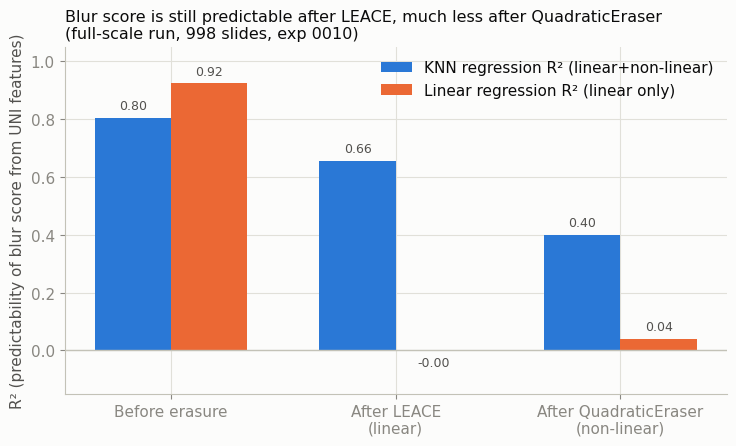

In [4]:
groups = ["Before erasure", "After LEACE\n(linear)", "After QuadraticEraser\n(non-linear)"]
knn_r2 = [
    r0010["before_erasure"]["compute_knn_regression_r2"],
    r0010["leace"]["compute_knn_regression_r2"],
    r0010["quadratic"]["compute_knn_regression_r2"],
]
linear_r2 = [
    r0010["before_erasure"]["compute_linear_regression_r2"],
    r0010["leace"]["compute_linear_regression_r2"],
    r0010["quadratic"]["compute_linear_regression_r2"],
]

x = np.arange(len(groups))
width = 0.34

fig, ax = plt.subplots(figsize=(7.5, 4.6))
b1 = ax.bar(x - width / 2, knn_r2, width, label="KNN regression R² (linear+non-linear)", color=BLUE)
b2 = ax.bar(x + width / 2, linear_r2, width, label="Linear regression R² (linear only)", color=ORANGE)

ax.axhline(0, color=BASELINE, linewidth=1)
for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        va = "bottom" if h >= 0 else "top"
        offset = 0.02 if h >= 0 else -0.02
        ax.text(rect.get_x() + rect.get_width() / 2, h + offset, f"{h:.2f}",
                ha="center", va=va, fontsize=9, color=INK_SECONDARY)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("R² (predictability of blur score from UNI features)")
ax.set_title("Blur score is still predictable after LEACE, much less after QuadraticEraser\n(full-scale run, 998 slides, exp 0010)", loc="left", fontsize=11.5)
ax.set_ylim(-0.15, 1.05)
ax.legend(frameon=False, loc="upper right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_blur_predictability_before_after.png", dpi=200, bbox_inches="tight")
plt.show()


## Fig 3 — has_finding(病理所見)判別性能への影響(0010、本レポートの主結果)

ぼやけを消去しても、臨床的に意味のある「病理所見の有無」判別性能(スライド平均プーリング
+ロジスティック回帰プローブ、5-fold CV)がほぼ落ちないことを示す。破線はchance level(0.5)。


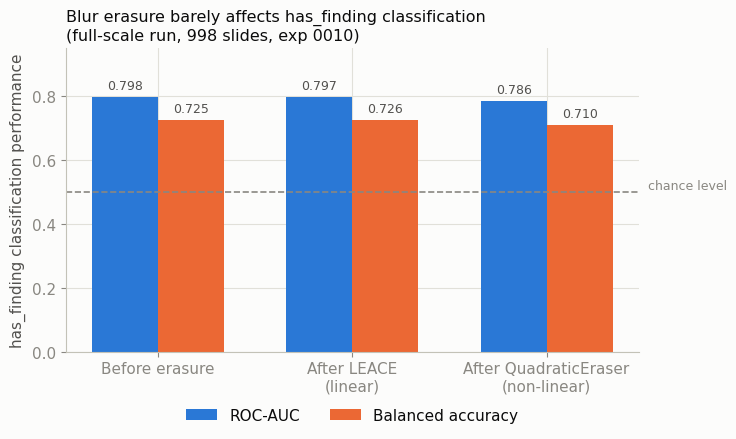

In [5]:
groups = ["Before erasure", "After LEACE\n(linear)", "After QuadraticEraser\n(non-linear)"]
roc_auc = [
    r0010["before_erasure"]["finding_probe"]["roc_auc"],
    r0010["leace"]["finding_probe"]["roc_auc"],
    r0010["quadratic"]["finding_probe"]["roc_auc"],
]
bal_acc = [
    r0010["before_erasure"]["finding_probe"]["balanced_accuracy"],
    r0010["leace"]["finding_probe"]["balanced_accuracy"],
    r0010["quadratic"]["finding_probe"]["balanced_accuracy"],
]

x = np.arange(len(groups))
width = 0.34

fig, ax = plt.subplots(figsize=(7.5, 4.6))
b1 = ax.bar(x - width / 2, roc_auc, width, label="ROC-AUC", color=BLUE)
b2 = ax.bar(x + width / 2, bal_acc, width, label="Balanced accuracy", color=ORANGE)

ax.axhline(0.5, color=INK_MUTED, linewidth=1.2, linestyle="--")
ax.text(len(groups) - 0.5, 0.5, " chance level", color=INK_MUTED, fontsize=9, va="bottom")

for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 0.015, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("has_finding classification performance")
ax.set_title("Blur erasure barely affects has_finding classification\n(full-scale run, 998 slides, exp 0010)", loc="left", fontsize=11.5)
ax.set_ylim(0, 0.95)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_has_finding_utility.png", dpi=200, bbox_inches="tight")
plt.show()


## Fig 4 — 消去による表現全体への影響(LEACE vs QuadraticEraser)

消去前後でのUNI特徴量ベクトルの変化を、コサイン類似度(方向の変化)と分散比(ノルムの変化)で見る。
QuadraticEraserの方がLEACEより表現を大きく動かしている(=より多くの情報を消している)ことと対応する。


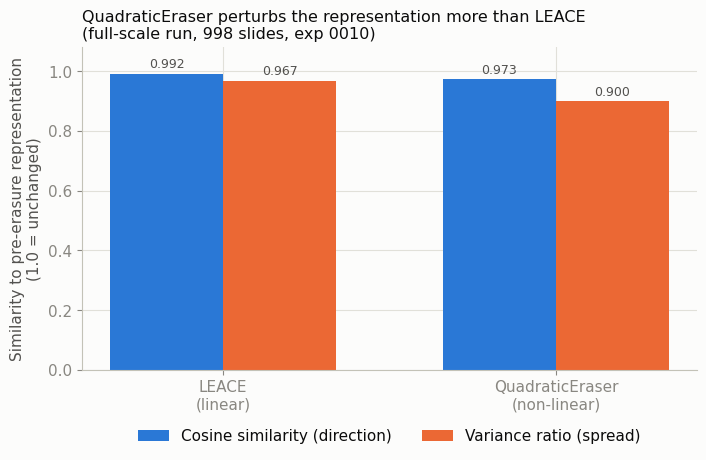

In [6]:
methods = ["LEACE\n(linear)", "QuadraticEraser\n(non-linear)"]
cos_sim = [
    r0010["leace"]["geometric_change"]["cosine_similarity_mean"],
    r0010["quadratic"]["geometric_change"]["cosine_similarity_mean"],
]
var_ratio = [
    r0010["leace"]["geometric_change"]["variance_ratio"],
    r0010["quadratic"]["geometric_change"]["variance_ratio"],
]

x = np.arange(len(methods))
width = 0.34

fig, ax = plt.subplots(figsize=(7.2, 4.8))
b1 = ax.bar(x - width / 2, cos_sim, width, label="Cosine similarity (direction)", color=BLUE)
b2 = ax.bar(x + width / 2, var_ratio, width, label="Variance ratio (spread)", color=ORANGE)

for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Similarity to pre-erasure representation\n(1.0 = unchanged)")
ax.set_title("QuadraticEraser perturbs the representation more than LEACE\n(full-scale run, 998 slides, exp 0010)", loc="left", fontsize=11.5)
ax.set_ylim(0, 1.08)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_geometric_change_leace_vs_quadratic.png", dpi=200, bbox_inches="tight")
plt.show()


## まとめ

| 図 | 内容 | 結論 |
|---|---|---|
| Fig 1 | ぼやけスコアの分布(998,000パッチ) | 後続実験のconceptラベルの基礎データ |
| Fig 2 | 消去前後のぼやけ予測可能性(R²) | LEACEは線形成分のみ除去、QuadraticEraserはより広く除去 |
| Fig 3 | has_finding判別性能への影響 | **どちらの消去でも臨床的に有用な信号はほぼ壊れない** |
| Fig 4 | 表現全体への幾何学的影響 | QuadraticEraserの方がLEACEより表現を大きく動かす(=より強く消している)ことと整合 |

生成した図は `notebooks/figures/` にPNGとして保存済み。
